# Eta-pool sweep — $p^\star$ phase transition and scale (k-means)
> **Purpose:** the paper's main-section eta-pool figures, reported for a single operator —
> **produces `pstar_gen_kmeans_2panel.png`** (phase transition vs scale, $\eta\in\{1,5,10,15\}$) and
> **`recovery_grid_kmeans.png`** (recovery-vs-$p$ grid, rows $n$ × cols $\eta$, no summary row —
> the two-panel figure already covers the scaling summary). **Data: generated** (dendropy
> Kingman; cached eta-pool).

| color | operator | Laplacian | threshold $\tau$ |
|---|---|---|---|
| gray  | `sign`   | $L=\mathrm{Deg}(S)-S$ | sign, $\tau=0$ (original STDR) |
| blue  | `sigma2` | $L=\mathrm{Deg}(S)-S$ | data-driven $\sigma_2$-gap |
| red   | `kmeans` | $L_{\rm sym}=I-D^{-1/2}SD^{-1/2}$ | data-driven k-means($k$=2) |

The main-text figures report only `kmeans` (`PAPER_METHOD` in
`src/utils/eta_pool_sweep.py`) — it is the operator the paper's recovery claims are stated
for. `sign` and `sigma2` are retained by the engine and appear only in the **Appendix**
section at the bottom of this notebook, which reproduces the original three-operator
$p^\star$-vs-$n$ comparison (`pstar_gen_3operators.png`). `sigma2` there is **cached-only**
(`CACHED_ONLY`) — plotted only where already on disk, never recomputed.

`n=8000` is excluded throughout (`NS_INCLUDE`): the eta-pool has exactly one completed sample
per $\eta$ at that size, vs. the $\ge 3$ samples backing every other $n$ — one sample would
inject unaggregated (k=1) noise into both the recovery-grid means and the $p^\star$ power-law
fits without adding a usable scale point.

## 1 · Setup & config

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while ROOT.parent != ROOT and not (ROOT / "setup.py").exists():
    ROOT = ROOT.parent
PROJECT_ROOT = ROOT / "sub_sampled_fielder_vec"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.eta_pool_sweep import (
    discover_ns_and_samples, run_and_collect_sweeps, collect_pool_features,
    P_VALUES,
)
from analysis.theoretical_interpretation.utils.sweep_plots import (
    plot_pstar_vs_n, plot_nmi_grid, plot_curves_per_n, plot_curves_per_eta,
)
from analysis.theoretical_interpretation.utils.sweep_plots_two_panel import (
    plot_pstar_pair, cbm_sufficient_p,
)

CACHE_ROOT = PROJECT_ROOT / "src" / "cache"
FIG_DIR = PROJECT_ROOT / "docs" / "overleafs" / "v9" / "figures"

# --- toggles -------------------------------------------------------------------
ETA_TARGETS = [1, 5, 10, 15]
ETA_MAIN    = [1, 5, 10, 15]   # rows shown in the main-text two-panel figure
#            (all four etas: the main figure carries the full stratification)
# n=8000 dropped: exactly one eta-pool sample per eta there (see intro markdown).
NS_INCLUDE  = [500, 1000, 2000, 4000, 6000, 8000]
METRIC      = "nmi"      # "nmi" | "ari" | "agreement"   (recovery metric)
AGG         = "mean"     # "mean" | "median"             (across pool samples)
THRESHOLD   = 0.90   # p* = smallest p with mean NMI >= THRESHOLD.
#             0.90 rather than 0.95: p* is read off a 25-point log grid, and at
#             0.95 the read-off lands on the flat top of the transition, where a
#             single noisy pool sample moves p* by a whole grid step.

# --- main-text operator: kmeans only (PAPER_METHOD) -----------------------------
# neutral dark grey — kmeans is now the only curve, so it must not collide with
# the red 0.95 threshold dashed line.
METHODS = [
    ("kmeans", "#374151", "-", "o"),
]
METHOD_NAMES = [m[0] for m in METHODS]
CACHED_ONLY: set = set()   # kmeans cache is complete over NS_INCLUDE x ETA_TARGETS

# --- appendix operators: all three, original colors (used only in §6 below) -----
APPENDIX_METHODS = [
    ("sign",   "#4b5563", "-",  "o"),   # unnorm + sign (tau=0) — original STDR
    ("sigma2", "#1d4ed8", "--", "s"),   # unnorm + sigma2-gap
    ("kmeans", "#b91c1c", "-",  "^"),   # norm   + k-means (L_sym)
]
APPENDIX_METHOD_NAMES = [m[0] for m in APPENDIX_METHODS]
APPENDIX_CACHED_ONLY = {"sigma2"}   # sigma2 has no n=3000/6000 pool sweep; never recompute

print(f"metric={METRIC}  agg={AGG}  methods={METHOD_NAMES}  cached_only={CACHED_ONLY}")
print(f"fig_dir={FIG_DIR}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
metric=nmi  agg=mean  methods=['kmeans']  cached_only=set()
fig_dir=/Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/docs/overleafs/v9/figures


## 2 · Discover available $n$ and samples

In [3]:
ns_all, samples_by_n_eta = discover_ns_and_samples(CACHE_ROOT, eta_targets=ETA_TARGETS)
ns = [n for n in ns_all if n in NS_INCLUDE]
print(f"Found n values: {ns}")
print(f"  {'n':>6}  " + "  ".join(f"eta={e:>2}" for e in ETA_TARGETS))
for n in ns:
    counts = [len(samples_by_n_eta.get((n, e), [])) for e in ETA_TARGETS]
    print(f"  {n:>6}  " + "  ".join(f"{c:>6d}" for c in counts))

Found n values: [500, 1000, 2000, 4000, 6000, 8000]
       n  eta= 1  eta= 5  eta=10  eta=15
     500      10      10       3       3
    1000      10      10       3       3
    2000      10      10       3       3
    4000      10      10       3       3
    6000      10      10       3       3
    8000       1       1       1       1


## 3 · Compute — run (or load) the k-means sweep (main text)

In [4]:
_counts = {"computed": 0, "cached": 0, "skipped": 0}

def _on_sweep(name, n, eta, idx, was_cached):
    if was_cached is None:
        _counts["skipped"] += 1
    elif was_cached:
        _counts["cached"] += 1
    else:
        _counts["computed"] += 1
        print(f"    COMPUTE {name:6s} n={n} eta={eta} idx={idx:04d}", flush=True)

results = run_and_collect_sweeps(
    ns=ns, eta_targets=ETA_TARGETS, methods=METHOD_NAMES,
    metric=METRIC, cached_only_methods=CACHED_ONLY, use_cache=True,
    verbose=False, on_sweep=_on_sweep,
)
print("sweep complete:",
      {m: sum(v.shape[0] for v in d.values()) for m, d in results.items()})
print(f"cache report: computed={_counts['computed']} cached={_counts['cached']} "
      f"skipped={_counts['skipped']}")

sweep complete: {'kmeans': 134}
cache report: computed=0 cached=134 skipped=0


## 4 · Figures

### Figure 1 — phase transition vs scale ($p^\star$; k-means; main text)

**One file per $\eta$** — `pstar_gen_kmeans_eta{eta}.png` — each holding its recovery-vs-$p$
panel beside its $p^\star(n)$ scale panel. The 2×2 tiling and the $\eta$ labels are done in
LaTeX (`subfigure` + `subcaption`), so nothing in the images names its own $\eta$; the $n$
legend is drawn once, in the $\eta=1$ file, since the colours are shared.

Scale panel: empirical $\hat p^\star$ markers against $C\log n/n$, the theorem's shape at
fixed $\eta$ with $C$ measured as the **median of the per-point ratios**
$p^\star_i/(\log n_i/n_i)$; the annotation gives $C$ and the max/min spread of those
per-point values.

The cell also prints eq:main_rate with its literal constant $8(1+\eta)^3\beta_0^2$ as a
diagnostic. It is not plotted: rebuilt from each size's own pool medians it swings by an
order of magnitude between neighbouring $n$, and it is `nan` wherever the measured margin
$\rho-\eta S_{\rm out}^{\max}$ is non-positive — at $\eta\ge10$, most sizes.

  eta= 1: margin=+0.564 +0.276 +0.434 +0.621 +0.635 +0.646   bound=0.0633 0.524 0.0532 0.0105 0.00568 0.00424
  eta= 5: margin=+0.592 +0.849 +0.664 +0.628 +0.409 +0.610   bound=0.311 0.0111 0.0434 0.0322 0.185 0.0289
  eta=10: margin=  n/a +0.517   n/a   n/a   n/a   n/a   bound=nan 0.602 nan nan nan nan
  eta=15: margin=+0.002   n/a   n/a   n/a +0.493   n/a   bound=3.04e+05 nan nan nan 0.176 nan
saved docs/overleafs/v9/figures/pstar_gen_kmeans_eta1.png
saved docs/overleafs/v9/figures/pstar_gen_kmeans_eta5.png
saved docs/overleafs/v9/figures/pstar_gen_kmeans_eta10.png
saved docs/overleafs/v9/figures/pstar_gen_kmeans_eta15.png


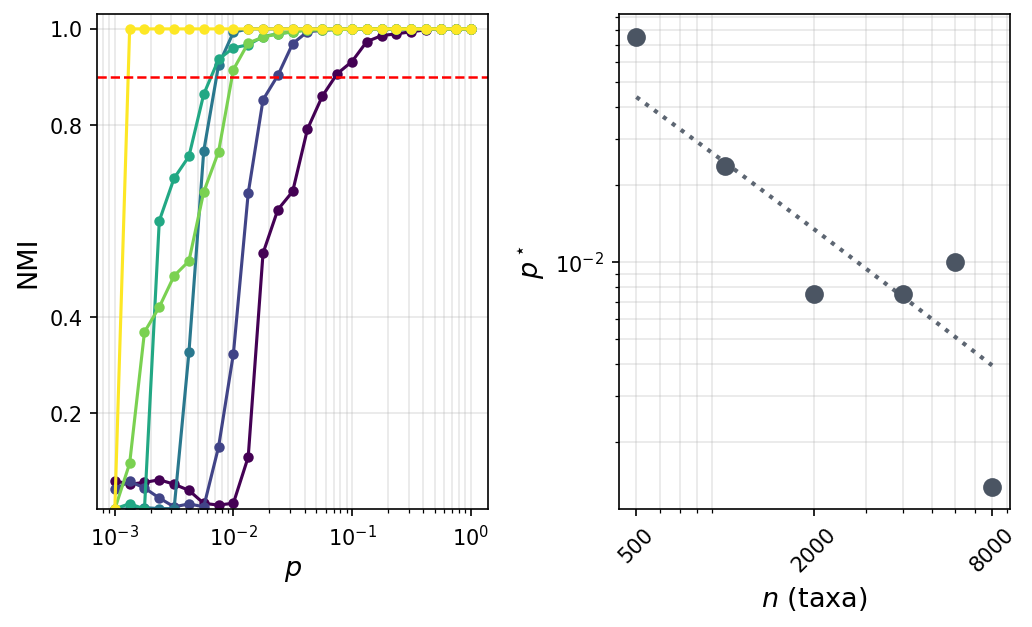

In [4]:
# Diagnostic only (not plotted): eq:main_rate with its literal constant,
#     p > 8 (1+eta)^3 (S_out^max)^2 log m / [m (rho - eta S_out^max)^2]
# from the per-(n,eta) pool-metadata medians. nan => the measured margin is <= 0,
# asm:margin fails on those samples and the certificate says nothing (cor:infeasible).
feats = collect_pool_features(ns, eta_targets=ETA_MAIN)
theory = {}
for eta in ETA_MAIN:
    row = np.full(len(ns), np.nan)
    for i, n in enumerate(sorted(ns)):
        f = feats.get((n, eta))
        if f is not None:
            row[i] = cbm_sufficient_p(eta, f["S_out_max"], f["margin"], n)
    theory[eta] = row
    print(f"  eta={eta:>2}: margin=" +
          " ".join(f"{feats[(n, eta)]['margin']:+.3f}" if (n, eta) in feats else "  n/a"
                   for n in sorted(ns)) +
          "   bound=" + " ".join("nan" if not np.isfinite(v) else f"{v:.3g}" for v in row))

# One file per eta; LaTeX tiles them 2x2, supplies the eta subcaptions, and
# carries the single shared key for curve colours and marker roles.
for eta in ETA_MAIN:
    plot_pstar_pair(
        results["kmeans"], P_VALUES, eta, ns,
        theory_row=theory[eta], metric_label=METRIC.upper(), agg=AGG,
        threshold=THRESHOLD,
        savepath=FIG_DIR / f"pstar_gen_kmeans_eta{eta}.png",
    )

### Figure 2 — recovery vs $p$ (rows $n$ × cols $\eta$; k-means; main text)

`summary=False` — the $p^\star$-vs-$n$ summary row is identical to Figure 1's right column
and would be redundant here. Saved to `recovery_grid_kmeans.png`.

saved /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/docs/overleafs/v9/figures/recovery_grid_kmeans.png


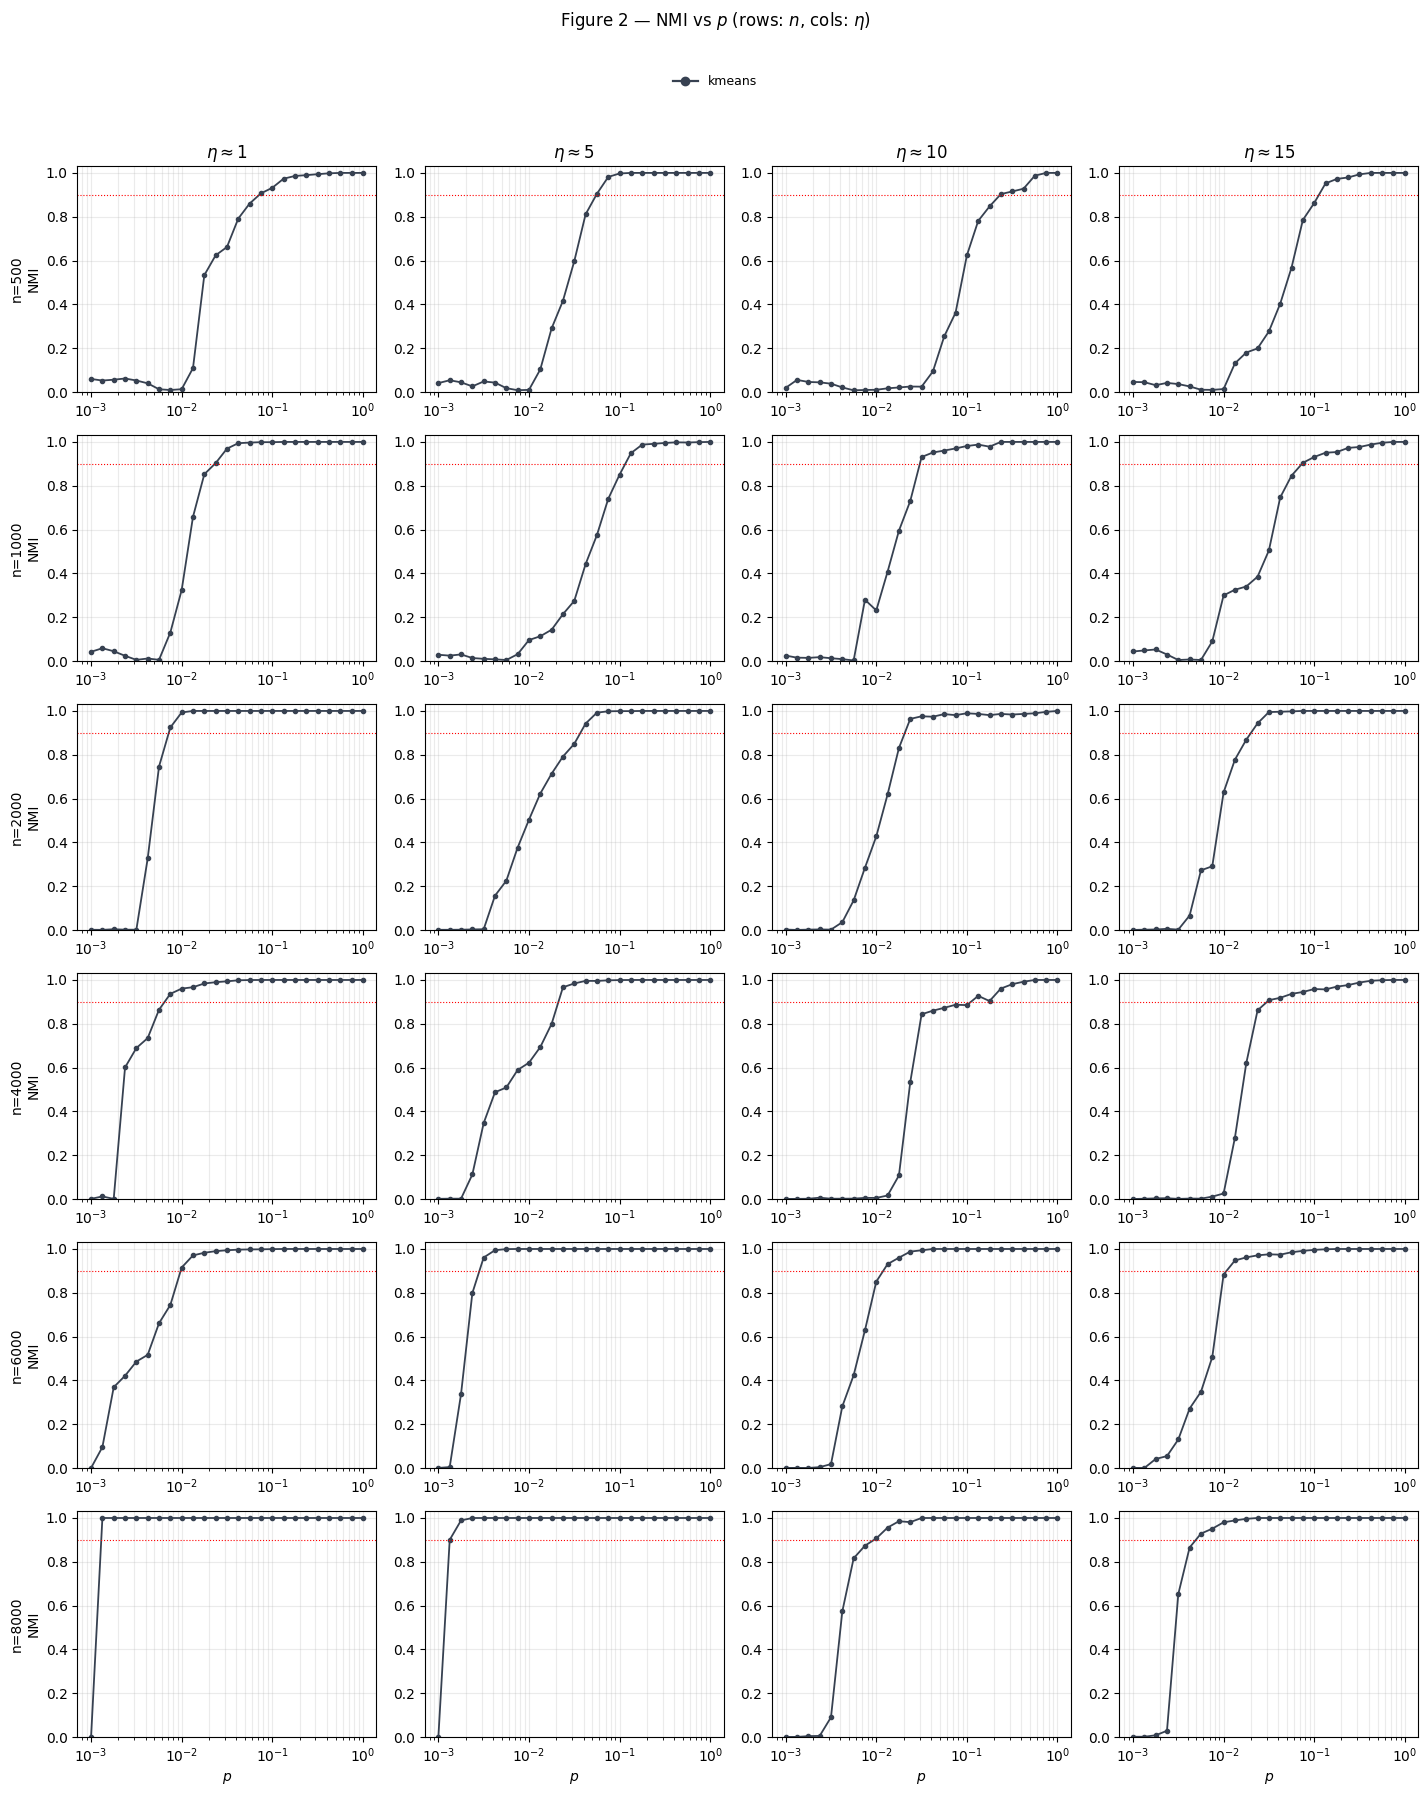

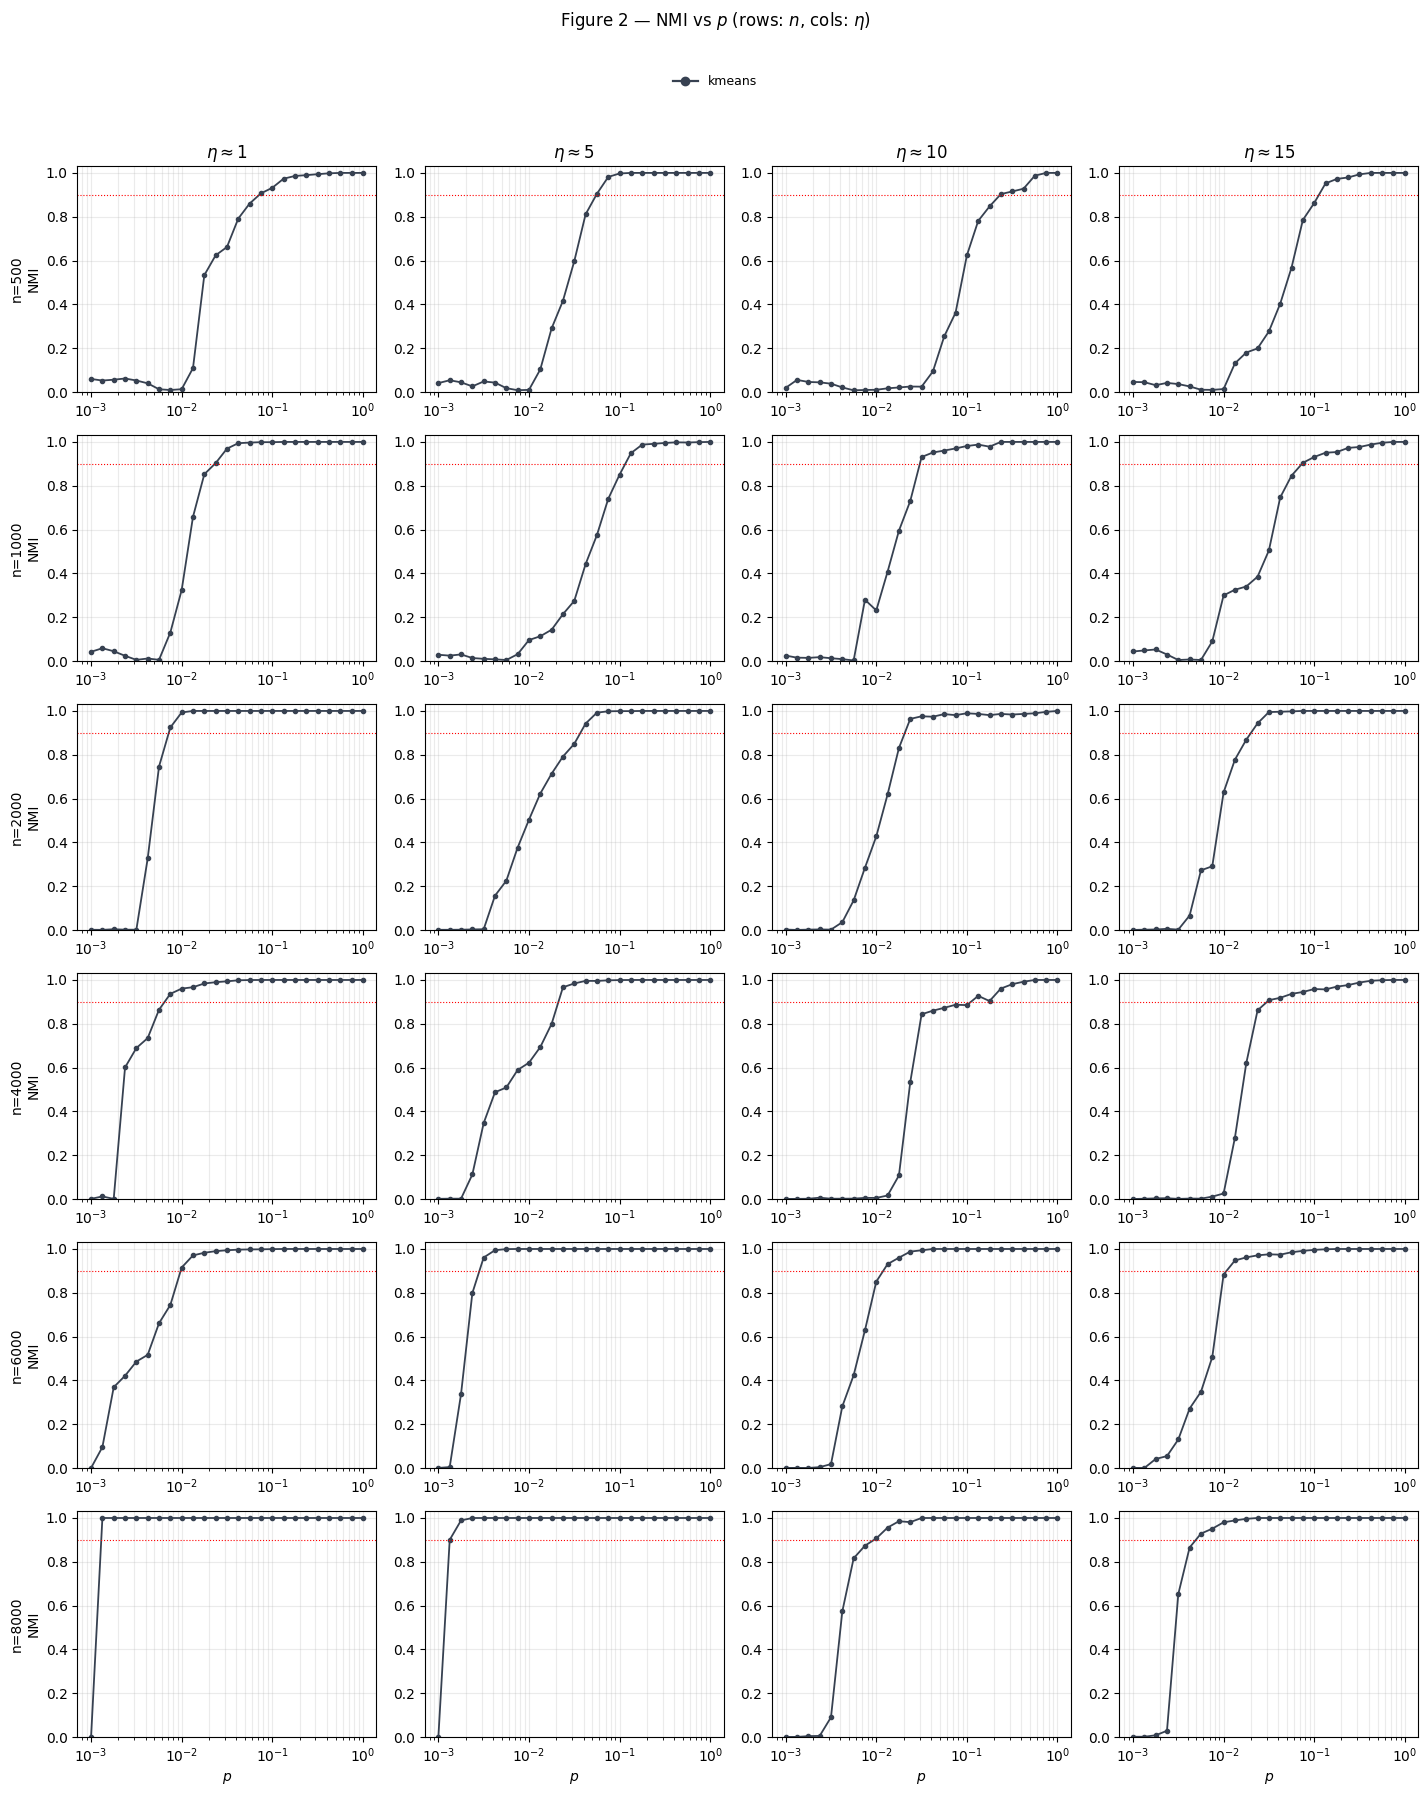

In [6]:
plot_nmi_grid(results, P_VALUES, ETA_TARGETS, ns, METHODS,
              agg=AGG, threshold=THRESHOLD, metric_label=METRIC.upper(), summary=False,
              savepath=FIG_DIR / "recovery_grid_kmeans.png")

### 5 · Reading the scale panel — definitions & fits

Applies to Figure 1's right column (and to the appendix $p^\star$-vs-$n$ figure below).

**Definitions**

| symbol | definition |
|---|---|
| $p$ | sampling rate: fraction of the $\tfrac{n(n-1)}{2}$ off-diagonal similarity entries observed |
| $p^\star$ | smallest $p$ with metric $\ge 0.95$ (grid-quantised recovery threshold) |
| $\#\mathrm{entries}(p)$ | $= p\cdot\tfrac{n(n-1)}{2}\ \propto\ p\,n^{2}$ |

**Fitted / overlay curves**

| curve | equation | meaning |
|---|---|---|
| dashed | $p^\star = A\,n^{b}\quad\Leftrightarrow\quad \log p^\star = a + b\log n$ | free power-law LS fit; $b$ = measured scaling exponent |
| dotted | $p^\star = C\,\dfrac{\log n}{n}$ | theoretical rate (matrix-completion / connectivity floor); $C$ by 1-param LS |
| dash-dot | $p > 8(1+\eta)^3\,(S_{out}^{\max})^2\log m \,/\,\bigl(m\,(\rho-\eta\,S_{out}^{\max})^2\bigr)$ | CBM sufficient-$p$ bound, Theorem thm:main-sim, from pool-metadata medians (Figure 1 only) |

**Entry budget at threshold** — substituting $p^\star$ into $\#\mathrm{entries}$:

| regime | $p^\star$ | $\#\mathrm{entries}\propto n^{\,b+2}$ | per row $\propto n^{\,b+1}$ | reading |
|---|---|---|---|---|
| theory | $\dfrac{\log n}{n}$ | $n\log n$ | $\log n$ | healthy floor |
| $b\approx-0.9$ | $n^{-0.9}$ | $n^{1.1}$ | $n^{0.1}$ (grows) | $\approx$ theory over this range |
| $b=-1$ | $n^{-1}$ | $n$ | const | linear entries |
| $b<-1$ | $n^{b}$ | $n^{\,b+2}\!<\!n$ | $n^{\,b+1}\!\to\!0$ (shrinks) | sub-floor $\Rightarrow$ likely fit artifact |

Note: a straight line on the log–log axes is a *pure* power law $n^{b}$; the dotted $C\log n/n$ curves because $\log(C\log n/n)=\log C-\log n+\log\log n$ carries the extra $\log\log n$ term.


## 6 · Appendix — three-operator comparison ($p^\star$ vs $n$)

Reproduces the original `sign` / `sigma2` / `kmeans` comparison over `APPENDIX_METHODS`.
`sigma2` is cached-only (`APPENDIX_CACHED_ONLY`) so it is plotted only where already on
disk (no `n`=3000/6000) and is never recomputed; `sign`/`kmeans` compute on demand
(cache-warm from §3 for `kmeans`). Saved to `pstar_gen_3operators.png`.

appendix sweep complete: {'sign': 134, 'sigma2': 108, 'kmeans': 134}
cache report: computed=0 cached=376 skipped=0
saved /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/docs/overleafs/v9/figures/pstar_gen_3operators.png


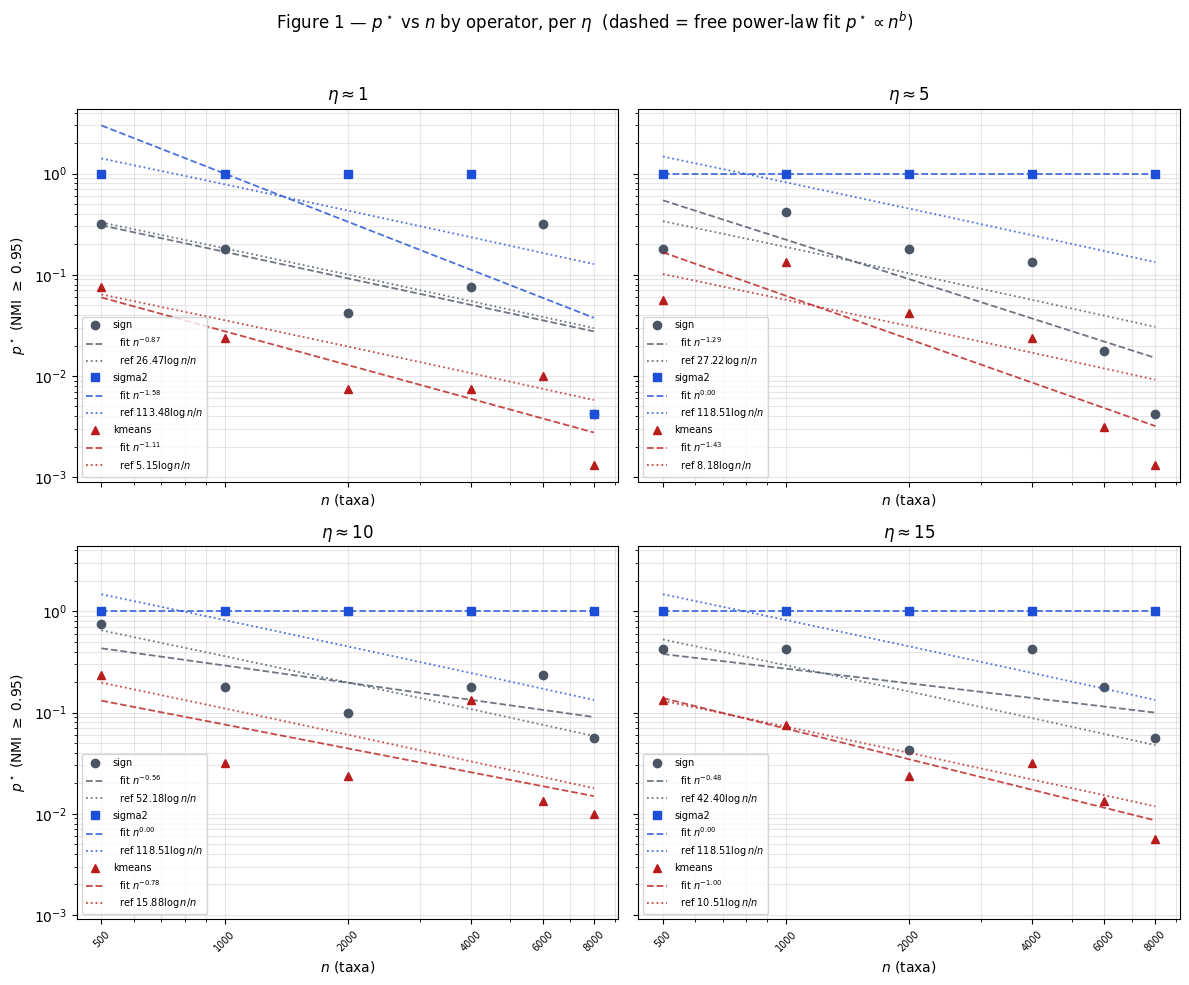

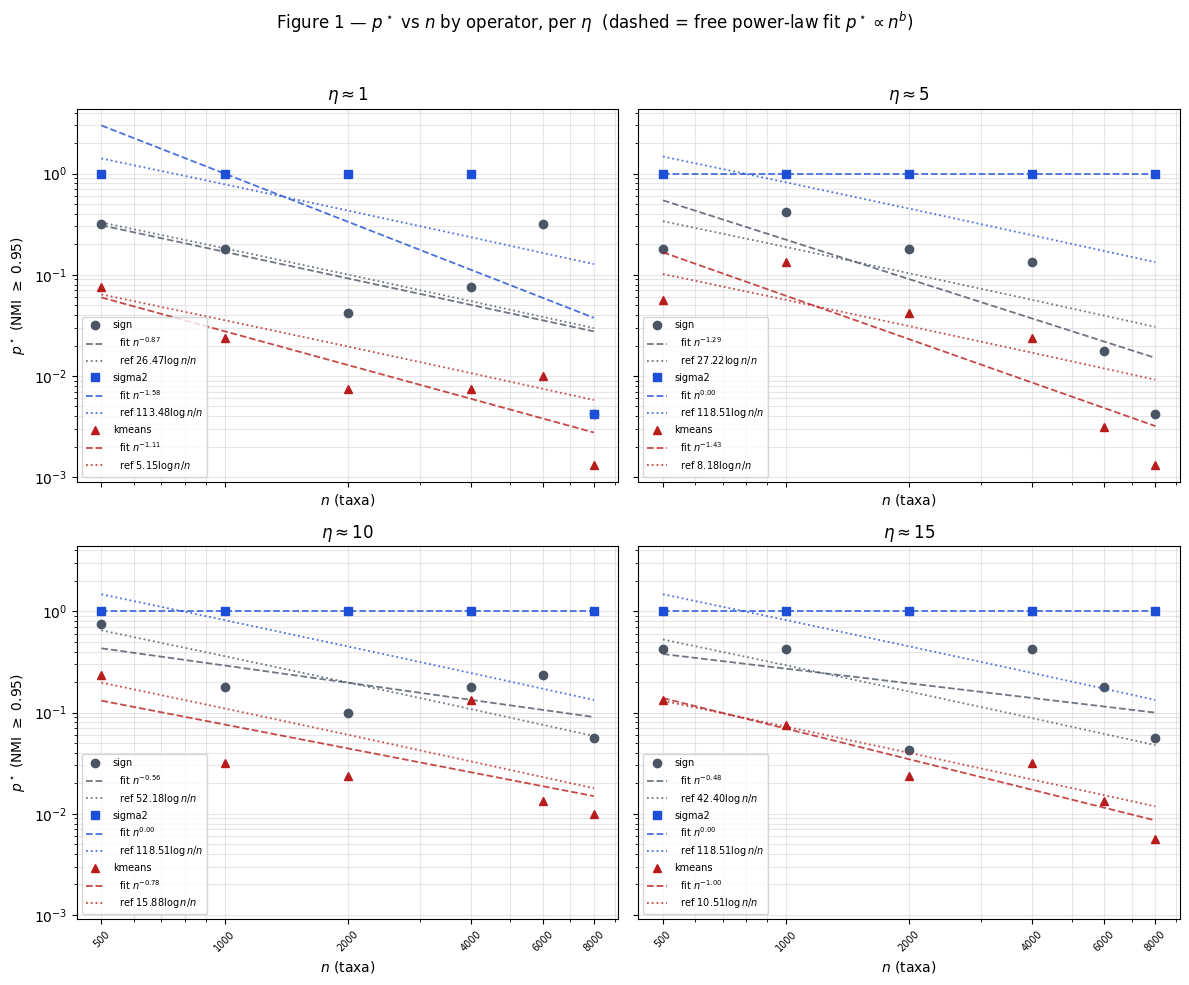

In [7]:
_appendix_counts = {"computed": 0, "cached": 0, "skipped": 0}

def _on_sweep_appendix(name, n, eta, idx, was_cached):
    if was_cached is None:
        _appendix_counts["skipped"] += 1
    elif was_cached:
        _appendix_counts["cached"] += 1
    else:
        _appendix_counts["computed"] += 1
        print(f"    COMPUTE {name:6s} n={n} eta={eta} idx={idx:04d}", flush=True)

appendix_results = run_and_collect_sweeps(
    ns=ns, eta_targets=ETA_TARGETS, methods=APPENDIX_METHOD_NAMES,
    metric=METRIC, cached_only_methods=APPENDIX_CACHED_ONLY, use_cache=True,
    verbose=False, on_sweep=_on_sweep_appendix,
)
print("appendix sweep complete:",
      {m: sum(v.shape[0] for v in d.values()) for m, d in appendix_results.items()})
print(f"cache report: computed={_appendix_counts['computed']} "
      f"cached={_appendix_counts['cached']} skipped={_appendix_counts['skipped']}")

plot_pstar_vs_n(appendix_results, P_VALUES, ETA_TARGETS, ns, APPENDIX_METHODS,
                agg=AGG, threshold=THRESHOLD,
                savepath=FIG_DIR / "pstar_gen_3operators.png")